In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score, roc_auc_score)

In [2]:
df = pd.read_csv(r'C:\Infoct_project 1 sample practice\dataset\predictive_maintenance.csv')
print("Dataset loaded!")
print(df.shape)

Dataset loaded!
(10000, 10)


In [3]:
# Week 2 external context
np.random.seed(42)
df['Ambient_temperature'] = np.random.normal(loc=295, scale=3, size=len(df))
df['Load_density'] = np.random.uniform(low=0.3, high=1.0, size=len(df))

# Week 1 engineered features
df["temp_difference"] = df["Process temperature [K]"] - df["Air temperature [K]"]
df["power"] = df["Rotational speed [rpm]"] * df["Torque [Nm]"]
df["tool_wear_rate"] = df["Tool wear [min]"] / df["Rotational speed [rpm]"]
df["heat_stress_index"] = df["Air temperature [K]"] * df["Tool wear [min]"]
df["wear_per_rotation"] = df["Tool wear [min]"] / df["Rotational speed [rpm]"] * 1000

# Week 3 new features
df["thermal_stress"] = df["temp_difference"] * df["tool_wear_rate"]
df["power_per_temp"] = df["power"] / df["Air temperature [K]"]

print("All features recreated!")
print(df.shape)

All features recreated!
(10000, 19)


In [7]:
# Final 12 features
final_features = ['Air temperature [K]', 'Process temperature [K]','Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]','temp_difference', 'power', 'tool_wear_rate',
'heat_stress_index', 'wear_per_rotation','thermal_stress', 'power_per_temp']

X = df[final_features]
Y = df['Target']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train LightGBM
model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    class_weight='balanced'
)
model.fit(X_train_scaled, Y_train)
print("Model trained successfully!")

[LightGBM] [Info] Number of positive: 271, number of negative: 7729
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000437 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2536
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Model trained successfully!


In [8]:
# Generate results for all noise levels
noise_levels = [0, 0.05, 0.10, 0.15, 0.20]
noise_labels = ['0%', '5%', '10%', '15%', '20%']

all_results = []

for noise, label in zip(noise_levels, noise_labels):
    np.random.seed(42)
    if noise == 0:
        X_test_noisy = X_test_scaled
    else:
        noise_data = np.random.normal(0, noise, X_test_scaled.shape)
        X_test_noisy = X_test_scaled + noise_data

    pred = model.predict(X_test_noisy)
    proba = model.predict_proba(X_test_noisy)[:, 1]

    all_results.append({
        'noise_level': label,
        'accuracy': accuracy_score(Y_test, pred),
        'precision': precision_score(Y_test, pred, average='macro'),
        'recall': recall_score(Y_test, pred, average='macro'),
        'f1_score': f1_score(Y_test, pred, average='macro'),
        'roc_auc': roc_auc_score(Y_test, proba)
    })

results_df = pd.DataFrame(all_results)
print("Results generated!")
print(results_df)

Results generated!
  noise_level  accuracy  precision    recall  f1_score   roc_auc
0          0%    0.9865   0.891256  0.907883  0.899381  0.973009
1          5%    0.9840   0.871369  0.892400  0.881569  0.971106
2         10%    0.9775   0.816819  0.874848  0.843151  0.971669
3         15%    0.9785   0.826749  0.868271  0.846147  0.971783
4         20%    0.9775   0.819995  0.860659  0.838991  0.969964


c:\Users\acer\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\acer\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\acer\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\acer\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\acer\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWa

In [9]:
# Performance comparison table
print("=== Performance Comparison Table ===")
results_df['f1_drop'] = results_df['f1_score'] - results_df['f1_score'].iloc[0]
results_df['f1_drop_%'] = (results_df['f1_drop'] / results_df['f1_score'].iloc[0] * 100).round(2)

print(results_df[['noise_level', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'f1_drop', 'f1_drop_%']].to_string())

=== Performance Comparison Table ===
  noise_level  accuracy  precision    recall  f1_score   roc_auc   f1_drop  f1_drop_%
0          0%    0.9865   0.891256  0.907883  0.899381  0.973009  0.000000       0.00
1          5%    0.9840   0.871369  0.892400  0.881569  0.971106 -0.017812      -1.98
2         10%    0.9775   0.816819  0.874848  0.843151  0.971669 -0.056231      -6.25
3         15%    0.9785   0.826749  0.868271  0.846147  0.971783 -0.053234      -5.92
4         20%    0.9775   0.819995  0.860659  0.838991  0.969964 -0.060390      -6.71


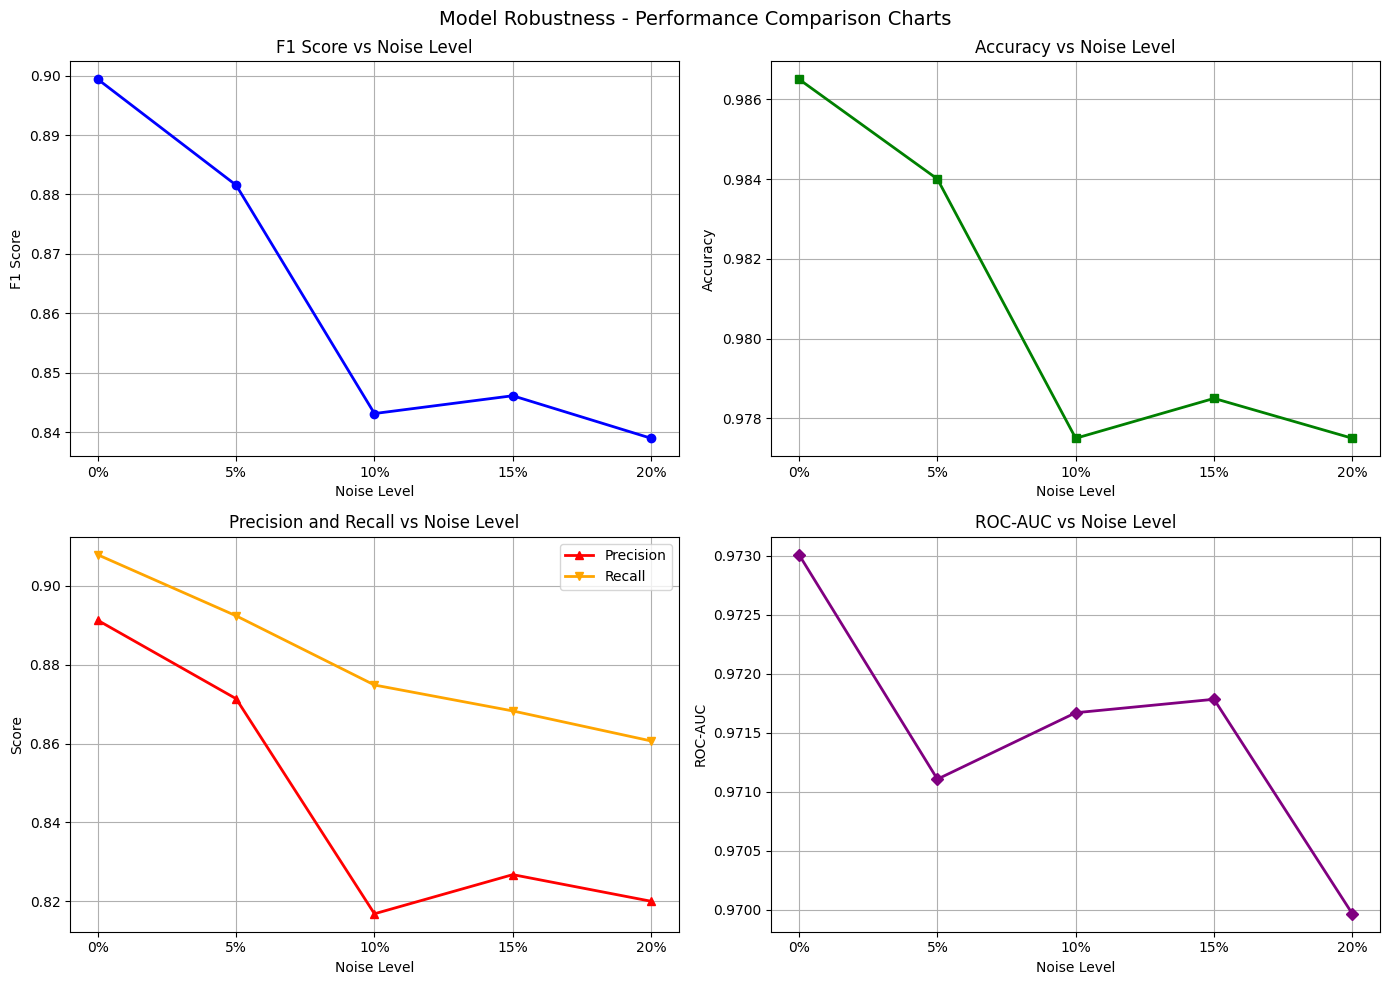

Charts saved!


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Robustness - Performance Comparison Charts', fontsize=14)

# Chart 1 - F1 Score
axes[0,0].plot(noise_labels, results_df['f1_score'], 
               marker='o', color='blue', linewidth=2)
axes[0,0].set_title('F1 Score vs Noise Level')
axes[0,0].set_xlabel('Noise Level')
axes[0,0].set_ylabel('F1 Score')
axes[0,0].grid(True)

# Chart 2 - Accuracy
axes[0,1].plot(noise_labels, results_df['accuracy'], 
               marker='s', color='green', linewidth=2)
axes[0,1].set_title('Accuracy vs Noise Level')
axes[0,1].set_xlabel('Noise Level')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].grid(True)

# Chart 3 - Precision and Recall
axes[1,0].plot(noise_labels, results_df['precision'], 
               marker='^', color='red', linewidth=2, label='Precision')
axes[1,0].plot(noise_labels, results_df['recall'], 
               marker='v', color='orange', linewidth=2, label='Recall')
axes[1,0].set_title('Precision and Recall vs Noise Level')
axes[1,0].set_xlabel('Noise Level')
axes[1,0].set_ylabel('Score')
axes[1,0].legend()
axes[1,0].grid(True)

# Chart 4 - ROC-AUC
axes[1,1].plot(noise_labels, results_df['roc_auc'], 
               marker='D', color='purple', linewidth=2)
axes[1,1].set_title('ROC-AUC vs Noise Level')
axes[1,1].set_xlabel('Noise Level')
axes[1,1].set_ylabel('ROC-AUC')
axes[1,1].grid(True)

plt.tight_layout()
plt.savefig(
    r'C:\Infoct_project 1 sample practice\Week4_Yogesh\comparison_charts.png')
plt.show()
print("Charts saved!")